In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
# import geopy.distances
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr, wilcoxon, pearsonr
import seaborn as sns
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import overlap_utils as ou

import data_utils as du
import numpy as np
import os
import tqdm
import scipy
import re
from functools import reduce
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import haversine_distances
from statsmodels.stats.multitest import multipletests



In [3]:

### LOAD DATA ###

# Initialise paths
data_folder = '../data/'
list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')

# Set data sources for which I have pixel values
modalities = ['alphaearth', 'tessera', 'satclip', 'geoclip'] 
samples = ['random_sample', 'lc_stratified_sample']
sample_ids = [gdf_points['id'][gdf_points[s]==1].to_numpy() for s in samples]
embeddings = [[du.load_csv_with_points(parent_folder=data_folder, modality=m, sample_type=s) 
               for s in samples] for m in modalities]

# Only included samples that are present across all modalities
common_samples = [[e['id'].to_numpy() for e in emb] for emb in embeddings]
common_samples = [reduce(np.intersect1d, ([s[i] for s in common_samples])) for i in range(len(samples))]
common_embeddings = [[e.set_index("id").loc[inc].reset_index(drop=True).to_numpy() for inc, e in zip(common_samples, emb)] for emb in embeddings]

# Load land cover data
# land_cover = [{id: du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')
#                for id in tqdm.tqdm(s_id)} for s_id in common_samples]
land_cover_names = [k for k in du.create_cmap_dynamic_world().keys()]

Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
Number of samples: 18973


In [4]:
# Choose which sample to plot for (s=0: random; s=1: stratified)
s = 1

# Show representational overlap localised around patches:
# compute across a region of nearest neighbours for each patch
# Get longitude and latitude for all patches
locs = [gdf_points.set_index("id").loc[samp].reset_index(drop=True)[['lat', 'lon']].to_numpy() for samp in common_samples]
loc = locs[s]

# Create a approximate distance matrix between all points
# This is inaccurate but fast; geodesic would be better, but slow
coords_rad = np.radians(loc)
dist_matrix = haversine_distances(coords_rad)


### CALCULATE CORRELATION DISTANCES ###

In [5]:
# Get correlation matrix across all pairs of samples
all_corr_mats = np.stack([np.corrcoef(e[s]) for e in common_embeddings])
# And get a similarity between land cover too
assert s == 1
lc_pix = np.load('../content/centre_pixel_lc_values.npy')  # precomputed for lc_stratified_sample, as loading tiffs is slow; shape (num_samples, num_lc_classes)
# lc_pix = np.stack([land_cover[s][i][:,64,64] for i in common_samples[s]]).transpose()
lc_pix_z = (lc_pix - np.mean(lc_pix, axis=-1, keepdims=True)) / np.std(lc_pix, axis=-1, keepdims=True)
lc_sim_mats = np.stack([1-np.square(lc[:,None] - lc[None,:]) for lc in lc_pix])
lc_weight_mats = np.stack([np.maximum(lc[:,None], lc[None,:]) for lc in lc_pix])

# I want just the upper triangle, both for distance and correlation; add radius for dist in km
dist_utri = dist_matrix[np.triu_indices(all_corr_mats.shape[-1],1)] * 6371.0
all_corr_utri = np.stack([m[np.triu_indices(all_corr_mats.shape[-1],1)] for m in all_corr_mats])
lc_sim_utri = np.stack([m[np.triu_indices(lc_sim_mats.shape[-1],1)] for m in lc_sim_mats])
lc_weight_utri = np.stack([m[np.triu_indices(lc_weight_mats.shape[-1],1)] for m in lc_weight_mats])

# Store the fitted characteristic distances
entropy_dist = []

/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4259597699.py:35: RuntimeWarning: divide by zero encountered in log
  ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4259597699.py:35: RuntimeWarning: divide by zero encountered in log
  ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4259597699.py:35: RuntimeWarning: divide by zero encountered in log
  ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4259597699.py:35: RuntimeWarning: divide by zero encountered in log
  ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4259597699.py:35: RuntimeWarning: divide by zero encountered in log
  ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4259597699.py:35: RuntimeWarning: divide by zero encountered in log
  ax1.imshow(np.log(hist[0].T),
/var/folde

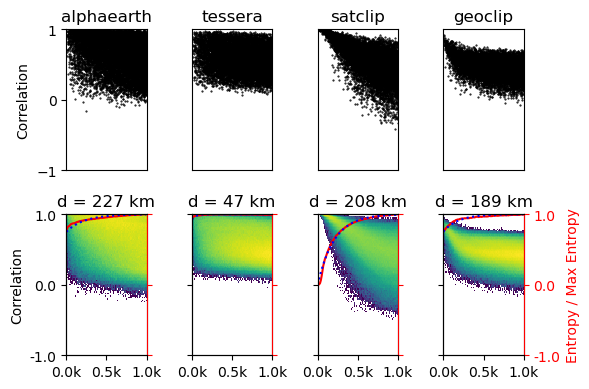

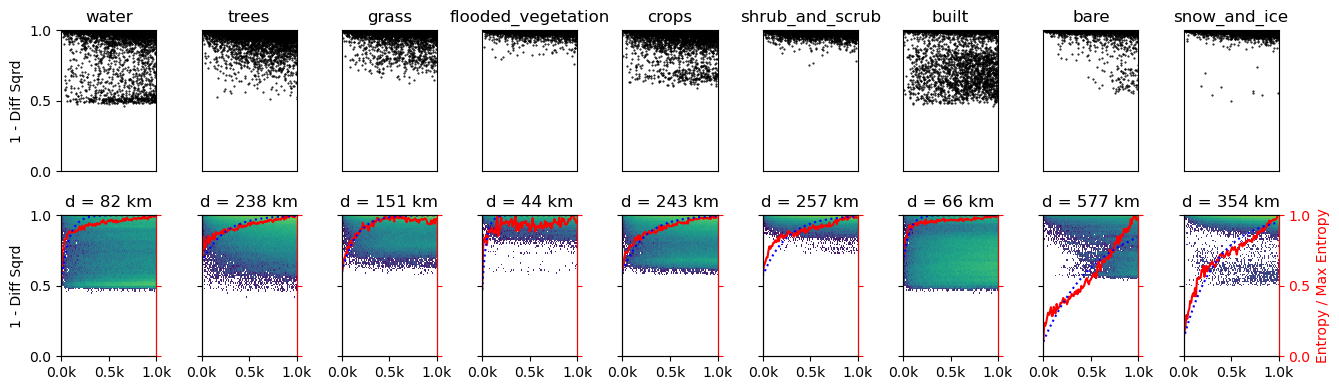

In [ ]:
# I could just plot all points, i.e. dist vs corr, but there are order 10k^2 so it's too many
# Instead, plot as subsample of points and make a heatmap of all of them
for sim_name, curr_sim, sim_lim, sim_names, sim_type, pair_weights in zip(
  ['emb', 'lc'], 
  [all_corr_utri, lc_sim_utri], 
  [[-1,1],[0,1]], 
  [modalities, land_cover_names], 
  ['Correlation','1 - Diff Sqrd'],
  [np.ones_like(all_corr_utri), lc_weight_utri]):
  
  # Plot at various distance cutoffs, which show the relevant scales
  for dist_cutoff in [1000]:#, 5000, np.max(dist_utri).astype(int)]:
    plt.figure(figsize=(len(sim_names)*1.5,4))
    for e, (points, weights, name) in enumerate(zip(curr_sim, pair_weights, sim_names)):
      include = dist_utri < dist_cutoff
      # Create a 2d histogram with similarity on y-ax and distance on x-ax
      hist = np.histogram2d(dist_utri[include], points[include], weights=weights[include], 
                            bins=100, range=[[0, np.max(dist_utri[include])], sim_lim], 
                            density=True)
      # First subplot: scatter plot of subsampled pairs
      plt.subplot(2, len(sim_names), e+1)
      steps = int(np.sum(include)/1e4)
      plt.plot(dist_utri[include][::steps], points[include][::steps], 'k.', markersize=1)
      plt.xlim([hist[1][0], hist[1][-1]])
      plt.ylim([hist[2][0], hist[2][-1]])
      if e == 0:
        plt.ylabel(sim_type)
        plt.yticks(np.linspace(sim_lim[0], sim_lim[1], 3))
      else:
        plt.yticks([])
      plt.xticks([])
      plt.title(name)
      # Second subplot: heatmap of log density
      ax1 = plt.subplot(2,len(sim_names), len(sim_names) + e+1)
      ax1.imshow(np.log(hist[0].T),
                interpolation='none',
                origin='lower',
                extent=[hist[1][0], hist[1][-1], hist[2][0], hist[2][-1]])   
      ax1.set_aspect('auto')
      # Plot the entropy on top
      ax2 = ax1.twinx()
      p = hist[0].T / np.sum(hist[0].T, axis=0, keepdims=True)
      entropy = -np.sum(p*np.log(np.clip(p, 1e-12, 1)), axis=0)
      # E = np.sum(p*hist[2][:-1][:,None], axis=0)
      ax2.plot(hist[1][:-1], entropy/np.max(entropy), 'r-')
      #ax2.plot(hist[1][:-1], E, 'k:')
      ax2.set_ylim([0,1])
      ax2.tick_params(axis="y", colors="red")
      ax2.spines["right"].set_color("red")            
      # Only for short distance cutoff: fit the entropy increase
      if dist_cutoff < 2000:
        pars = scipy.optimize.curve_fit(lambda t,d: (entropy[0]/np.max(entropy)-1)*np.exp(-t/d)+1,  
                                        hist[1][:-1] / hist[1][-2],  
                                        entropy/np.max(entropy),
                                        p0=[100/hist[1][-2]],
                                        maxfev=int(1e5)
                                        )[0]
        ax2.plot(hist[1][:-1], (entropy[0]/np.max(entropy)-1)* np.exp(-hist[1][:-1] / (pars[0] * hist[1][-2])) + 1, 'b:')  
        entropy_dist.append(pars[0]*hist[1][-1])      
        plt.title(label=f'd = {pars[0]*hist[1][-1]:.0f} km')
      # Annotate both axes
      ax1.set_yticks(np.linspace(sim_lim[0], sim_lim[1], 3), [])
      ax2.set_yticks(np.linspace(sim_lim[0], sim_lim[1], 3), [])
      if e == 0:
        ax1.set_ylabel(sim_type)
        ax1.set_yticks(np.linspace(sim_lim[0], sim_lim[1], 3), np.linspace(sim_lim[0], sim_lim[1], 3))
      if e == len(sim_names)-1:
        ax2.set_ylabel('Entropy / Max Entropy', color='red')
        ax2.set_yticks(np.linspace(sim_lim[0], sim_lim[1], 3), np.linspace(sim_lim[0], sim_lim[1], 3))  
      plt.xticks(np.linspace(0, np.max(dist_utri[include]), 3), [f'{d/1000:0.1f}k' for d in np.linspace(0, np.max(dist_utri[include]), 3)])
      plt.xlabel('Distance (km)')    
      plt.tight_layout()

In [7]:
r2_scores = pd.read_csv('../outputs/r2_scores_lc_classes.csv', index_col=0)
compl_scores = pd.read_csv('../outputs/complementarity_lc_classes.csv', index_col=0) 

dict_col_rename = {c: c.lstrip(r"\textit{").rstrip('}').rstrip('.').lower() for c in r2_scores.columns}
r2_scores.rename(columns=dict_col_rename, inplace=True)
compl_scores.rename(columns=dict_col_rename, inplace=True)

r2_scores = r2_scores[:4]

In [ ]:
save_tables = False

r_dicts, p_vals = [], []
dict_results_spatial = {x: [] for x in ['model', 'metric', 'spearman_r', 'p_value']}
for metric, data in zip(['r2', 'compl'], [r2_scores, compl_scores]):
    names = list(data.index)
    values = data.values

    # print(values)
    # # Calculate correlations with land cover spatial scale
    r_dicts.append({n: scipy.stats.spearmanr(v, np.stack([e for e in entropy_dist[4:]]), alternative='greater') for n, v in zip(names, values)})
    p_vals.append({n: v.pvalue for n,v in r_dicts[-1].items()})

    dict_results_spatial['model'].extend(names)
    dict_results_spatial['metric'].extend([metric] * len(values))
    dict_results_spatial['spearman_r'].extend([v.correlation for n, v in r_dicts[-1].items()])
    dict_results_spatial['p_value'].extend([v.pvalue for n, v in r_dicts[-1].items()])

df_results_spatial = pd.DataFrame(dict_results_spatial)
df_results_spatial['p_value_adj'] = np.nan
df_results_spatial.loc[range(4), 'p_value_adj'] = multipletests(df_results_spatial['p_value'][:4], method='fdr_bh', alpha=0.05)[1]
df_results_spatial.loc[range(4, len(df_results_spatial)), 'p_value_adj'] = multipletests(df_results_spatial['p_value'][4:], method='fdr_bh', alpha=0.05)[1]
df_results_spatial['val_print'] = df_results_spatial.apply(lambda row: f"{row['spearman_r']:.2f}" + ('***' if row['p_value_adj'] < 0.001 else '**' if row['p_value_adj'] < 0.01 else '*' if row['p_value_adj'] < 0.05 else ''), axis=1)
df_results_spatial['val_print'] = df_results_spatial.apply(lambda row: r"$\textbf{" + row['val_print'] + "}$" if row['p_value_adj'] < 0.05 else row['val_print'], axis=1)
df_results_spatial.rename(columns={'model': 'Embeddings'}, inplace=True)
df_results_spatial_r2 = df_results_spatial[df_results_spatial['metric'] == 'r2']
df_results_spatial_compl = df_results_spatial[df_results_spatial['metric'] == 'compl']

df_results_spatial_r2.drop(columns=['metric', 'p_value', 'p_value_adj', 'spearman_r'], inplace=True)
df_results_spatial_compl.drop(columns=['metric', 'p_value', 'p_value_adj', 'spearman_r'], inplace=True)
df_results_spatial_r2 = df_results_spatial_r2.rename(columns={'val_print': r'$\rho(R^2, d)$'})
df_results_spatial_compl = df_results_spatial_compl.rename(columns={'val_print': r'$\rho(C^\text{LC}, d)$'})

df_results_spatial_compl = df_results_spatial_compl.reset_index(drop=True)

caption_r2 = "Spearman correlation between the characteristic distance of each land cover class $d$ and the $R^2$ prediction score for that land cover class from single-GFM embeddings."
caption_compl = "Spearman correlation between the characteristic distance of each land cover class $d$ and the complementarity score of an embedding pair. "

if save_tables:
    df_results_spatial_r2.to_latex('../tables/spatial_relationship_r2.tex', index=False,
                                   escape=False, caption=caption_r2, label='tab:spatial_r2')
    df_results_spatial_compl.to_latex('../tables/spatial_relationship_compl.tex', index=False,
                                       escape=False, caption=caption_compl, label='tab:spatial_compl')
    
df_results_spatial

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/2908256970.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_spatial_r2.drop(columns=['metric', 'p_value', 'p_value_adj', 'spearman_r'], inplace=True)
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/2908256970.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_spatial_compl.drop(columns=['metric', 'p_value', 'p_value_adj', 'spearman_r'], inplace=True)


,Embeddings,metric,spearman_r,p_value,p_value_adj,val_print
0,alphaearth,r2,0.400000,0.143053,0.143053,0.40
1,tessera,r2,0.450000,0.112108,0.143053,0.45
2,geoclip,r2,0.683333,0.021221,0.042442,$\textbf{0.68*}$
3,satclip,r2,0.800000,0.004814,0.019256,$\textbf{0.80*}$
4,alphaearth + tessera,compl,0.166667,0.334116,0.334116,0.17
5,alphaearth + geoclip,compl,0.600000,0.043811,0.051113,0.60
6,alphaearth + satclip,compl,0.816667,0.003612,0.025287,$\textbf{0.82*}$
7,tessera + geoclip,compl,0.700000,0.017885,0.037137,$\textbf{0.70*}$
8,tessera + satclip,compl,0.683333,0.021221,0.037137,$\textbf{0.68*}$
9,geoclip + satclip,compl,0.633333,0.033543,0.046960,$\textbf{0.63*}$


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4140774999.py:35: RuntimeWarning: divide by zero encountered in log
  im = ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4140774999.py:35: RuntimeWarning: divide by zero encountered in log
  im = ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4140774999.py:35: RuntimeWarning: divide by zero encountered in log
  im = ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4140774999.py:35: RuntimeWarning: divide by zero encountered in log
  im = ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4140774999.py:35: RuntimeWarning: divide by zero encountered in log
  im = ax1.imshow(np.log(hist[0].T),
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_56613/4140774999.py:35: RuntimeWarning: divide by zero encountered in log
  im = ax1.imshow

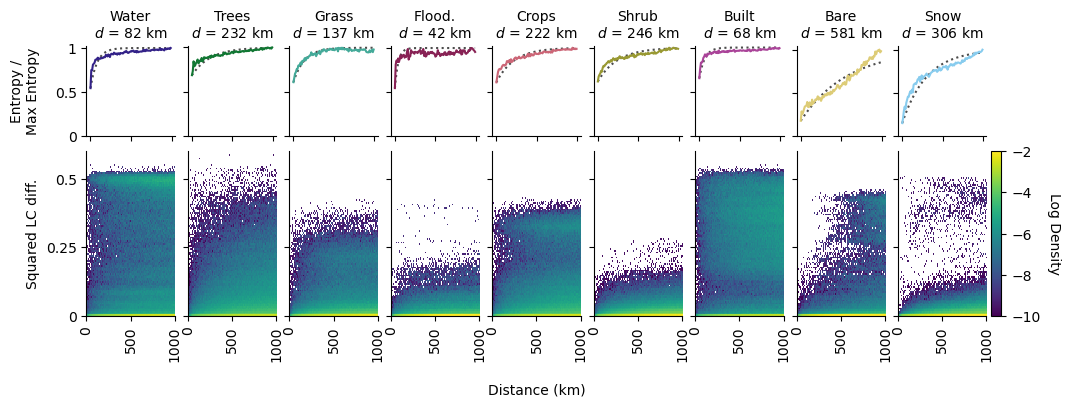

In [ ]:
save_fig = False

cmap_lc = du.create_cmap_dynamic_world()
name_dict_lc = {name: name.split('_')[0].title().replace('Flooded', 'Flood.') for name in land_cover_names}

entropy_curves = []
entropy_fit = []

sim_name = 'lc'
curr_sim = lc_sim_utri
sim_lim = [0, 0.6]
ent_lim = [0, 1.1]
sim_names = land_cover_names
pair_weights = lc_weight_utri

dist_cutoff = 1000

fig = plt.figure(figsize=(10, 3))
gs_entropy = fig.add_gridspec(1, len(sim_names), wspace=0.15, hspace=0.05, left=0.05, right=0.95, bottom=0.65, top=0.95)
gs_density = fig.add_gridspec(1, len(sim_names), wspace=0.15, hspace=0.05, left=0.05, right=0.95, bottom=0.05, top=0.6)
gs_cbar = fig.add_gridspec(1, 1, left=0.955, right=0.965, bottom=0.05, top=0.6)
ax_cbar = plt.subplot(gs_cbar[0,0])

for e, (points, weights, name) in enumerate(zip(curr_sim, pair_weights, sim_names)):
  points = 1 - points
  include = dist_utri < dist_cutoff
  
  # Create a 2d histogram with similarity on y-ax and distance on x-ax
  hist = np.histogram2d(dist_utri[include], points[include], weights=weights[include], 
                        bins=100, range=[[0, np.max(dist_utri[include])], sim_lim], 
                        density=True)
  
  # Second subplot: heatmap of log density
  ax1 = plt.subplot(gs_density[0, e])
  im = ax1.imshow(np.log(hist[0].T),
            interpolation='none',
            origin='lower',
            rasterized=False,
            vmin=-10, vmax=-2,
            extent=[hist[1][0], hist[1][-1], hist[2][0], hist[2][-1]])   
  ax1.set_aspect('auto')

  if e == len(sim_names)-1:
    cbar = plt.colorbar(im, cax=ax_cbar)
    cbar.set_label('Log Density', rotation=270, labelpad=15)

  # Plot the entropy on top
  ax2 = plt.subplot(gs_entropy[0, e])
  p = hist[0].T / np.sum(hist[0].T, axis=0, keepdims=True)
  entropy = -np.sum(p*np.log(np.clip(p, 1e-12, 1)), axis=0)
  entropy_curves.append(entropy)
  # E = np.sum(p*hist[2][:-1][:,None], axis=0)
  ax2.plot(hist[1][:-1], entropy/np.max(entropy), c=cmap_lc[name])

  # Only for short distance cutoff: fit the entropy increase
  if dist_cutoff < 2000:
    pars = scipy.optimize.curve_fit(lambda t,d: (entropy[0]/np.max(entropy)-1)*np.exp(-t/d)+1,  
                                    hist[1][:-1] / hist[1][-2],  
                                    entropy/np.max(entropy),
                                    p0=[100/hist[1][-2]],
                                    maxfev=int(1e5)
                                    )[0]
    ax2.plot(hist[1][:-1], (entropy[0]/np.max(entropy)-1)* np.exp(-hist[1][:-1] / (pars[0] * hist[1][-2])) + 1, 'k:', alpha=0.7, zorder=-1)     
    entropy_fit.append((entropy[0]/np.max(entropy)-1)* np.exp(-hist[1][:-1] / (pars[0] * hist[1][-2])) + 1)

    ax2.set_title(label=f'{name_dict_lc[name]}\n' + r"$d$" + f' = {pars[0]*hist[1][-1]:.0f} km', fontsize=10)

  # Annotate both axes
  ax1.set_yticks([0, 0.25, 0.5], [])
  ax2.set_yticks([0, 0.5, 1], []) 

  if e == 0:
    ax1.set_ylabel('Squared LC diff.')
    ax1.set_yticks([0, 0.25, 0.5], ['0', '0.25', '0.5'])
    ax2.set_ylabel('Entropy /\nMax Entropy')
    ax2.set_yticks([0, 0.5, 1], ['0', '0.5', '1'])  
    fig.align_ylabels([ax1, ax2])

  ax2.set_xticks([0, 500, 1000], [])
  ax1.set_xticks([0, 500, 1000], ['0', '500', '1000'], rotation=90)
  if e == 4:
    ax1.set_xlabel('\nDistance (km)')    

  for sp in ['top', 'right']:
    ax1.spines[sp].set_visible(False)
    ax2.spines[sp].set_visible(False)

if save_fig:
  plt.savefig(f'../figs/spatial_relationship_entropy_lc.pdf', bbox_inches='tight')